In [1]:
import json
import pandas as pd
import numpy as np

# Load the JSON file (already downloaded from Module 7)
with open("applicant_data_SM.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)

# Show first 5 rows
df.head()

,url,institution,program,degree,country_of_origin,decision,notification,undergrad_gpa,gre_general,gre_verbal,gre_aw,comments,date_added,start_term,notes
0,https://www.thegradcafe.com/result/919377,Florida State University (FSU),Communication Sciences And Disorders,Masters,American,Accepted,on 15/02/2024 via E-mail,3.40,0,0,0.00,None,None,None,accepted today for online (DL Program)!
1,https://www.thegradcafe.com/result/919378,Boston University,Sociology,PhD,American,Rejected,on 15/02/2024 via E-mail,3.70,0,0,0.00,None,None,None,No GRE. Was a genuinely good fit :( losing hop...
2,https://www.thegradcafe.com/result/919379,University Of Pittsburgh,Clinical Psychology,PhD,American,Wait listed,on 15/02/2024 via E-mail,0.00,0,0,0.00,None,None,None,IGNORE STATUS: Has anyone received information...
3,https://www.thegradcafe.com/result/919380,Massachusetts Institute of Technology (MIT),Physics,PhD,International,Rejected,on 15/02/2024 via E-mail,0.00,0,0,0.00,None,None,None,
4,https://www.thegradcafe.com/result/919381,Massachusetts Institute of Technology (MIT),Mechanical Engineering,PhD,International,Rejected,on 15/02/2024 via E-mail,3.80,0,0,0.00,None,None,None,"Masters Degree in ME, 2 years of research/work..."


In [2]:
raw_df = df.copy()

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Rows: 4500
Columns: 15

Column names:
['url', 'institution', 'program', 'degree', 'country_of_origin', 'decision', 'notification', 'undergrad_gpa', 'gre_general', 'gre_verbal', 'gre_aw', 'comments', 'date_added', 'start_term', 'notes']

Data types:
url                  object
institution          object
program              object
degree               object
country_of_origin    object
decision             object
notification         object
undergrad_gpa        object
gre_general          object
gre_verbal           object
gre_aw               object
comments             object
date_added           object
start_term           object
notes                object
dtype: object


In [4]:
# Count missing values per column
missing_counts = df.isna().sum()

# Percentage of missing values
missing_percent = (missing_counts / len(df)) * 100

# Combine into one table
missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

# Show the table
missing_df

,missing_count,missing_percent
url,0,0.000000
institution,1,0.022222
program,1,0.022222
degree,1,0.022222
country_of_origin,1,0.022222
decision,1,0.022222
notification,1,0.022222
undergrad_gpa,1,0.022222
gre_general,1,0.022222
gre_verbal,1,0.022222


In [5]:
missing_df.to_csv("missingness_summary.csv", index=True)

In [6]:
# Remove rows where program is missing
df = df[df["program"].notna()]

In [7]:
print("Raw rows:", raw_df.shape[0])
print("After removing missing program:", df.shape[0])
print("Rows removed:", raw_df.shape[0] - df.shape[0])

Raw rows: 4500
After removing missing program: 4499
Rows removed: 1


In [8]:
# Clean text columns (strip spaces and fix weird spacing)
text_columns = [
    "institution", "program", "degree", "country_of_origin",
    "decision", "notification", "comments", "notes"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

## Program and University columns

The raw dataset already contains separate `program` and `institution` columns, so no additional splitting step was required. I retained these columns as the cleaned Program and University fields.

In [9]:
# Count occurrences of each program
program_counts = df["program"].value_counts()

# Show programs with fewer than 3 occurrences
low_programs = program_counts[program_counts < 3]

low_programs

program
Art And Museum Studies                            2
Industrial and Operations Engineering             2
Health Services Research and Policy               2
Mass Communications                               2
History and Philosophy of Science and Medicine    2
                                                 ..
Social Anthropology                               1
Earth, Environmental And Planetary Sciences       1
Geological And Planetary Sciences                 1
Medicinal Chemistry And Molecular Pharmacology    1
Political Studies                                 1
Name: count, Length: 753, dtype: int64

In [10]:
print(df["notification"].head(10))
print()
print(df["start_term"].head(10))

0     on 15/02/2024 via E-mail
1     on 15/02/2024 via E-mail
2     on 15/02/2024 via E-mail
3     on 15/02/2024 via E-mail
4     on 15/02/2024 via E-mail
5    on 15/02/2024 via Website
6     on 15/02/2024 via E-mail
7     on 15/02/2024 via E-mail
8     on 14/02/2024 via E-mail
9     on 15/02/2024 via E-mail
Name: notification, dtype: object

0    None
1    None
2    None
3    None
4    None
5    None
6    None
7    None
8    None
9    None
Name: start_term, dtype: object


In [11]:
# Extract date from notification column
df["decision_date"] = df["notification"].str.extract(r"(\d{2}/\d{2}/\d{4})")

# Convert to datetime
df["decision_date"] = pd.to_datetime(df["decision_date"], format="%d/%m/%Y", errors="coerce")

df[["notification", "decision_date"]].head()

,notification,decision_date
0,on 15/02/2024 via E-mail,2024-02-15
1,on 15/02/2024 via E-mail,2024-02-15
2,on 15/02/2024 via E-mail,2024-02-15
3,on 15/02/2024 via E-mail,2024-02-15
4,on 15/02/2024 via E-mail,2024-02-15


In [12]:
# Standardize outcome labels from the decision column
df["outcome"] = df["decision"].replace({
    "Wait listed": "Waitlisted",
    "Interview": "Interviewed"
})

df[["decision", "outcome", "decision_date"]].head(10)

,decision,outcome,decision_date
0,Accepted,Accepted,2024-02-15
1,Rejected,Rejected,2024-02-15
2,Wait listed,Waitlisted,2024-02-15
3,Rejected,Rejected,2024-02-15
4,Rejected,Rejected,2024-02-15
5,Wait listed,Waitlisted,2024-02-15
6,Accepted,Accepted,2024-02-15
7,Accepted,Accepted,2024-02-15
8,Interview,Interviewed,2024-02-14
9,Accepted,Accepted,2024-02-15


In [13]:
valid_degrees = ["Masters", "PhD", "PsyD"]

before = df.shape[0]

df = df[df["degree"].isin(valid_degrees)]

after = df.shape[0]

print("Rows removed (invalid degree):", before - after)

Rows removed (invalid degree): 184


In [14]:
df["country_of_origin"].value_counts(dropna=False)

country_of_origin
International    2208
American         2107
Name: count, dtype: int64

In [15]:
df["us_international"] = df["country_of_origin"].replace({
    "American": "American",
    "International": "International"
})

df["us_international"].value_counts(dropna=False)

us_international
International    2208
American         2107
Name: count, dtype: int64

In [16]:
numeric_columns = [
    "undergrad_gpa",
    "gre_general",
    "gre_verbal",
    "gre_aw"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

df[numeric_columns].dtypes

undergrad_gpa    float64
gre_general      float64
gre_verbal       float64
gre_aw           float64
dtype: object

In [17]:
# Valid GPA (0–4)
df["has_valid_gpa"] = np.where(
    (df["undergrad_gpa"].notna()) & (df["undergrad_gpa"] >= 0) & (df["undergrad_gpa"] <= 4.0),
    1,
    0
)

# Valid GRE
df["has_valid_gre"] = np.where(
    (df["gre_general"].notna()) & (df["gre_general"] > 0),
    1,
    0
)

# Valid GRE Verbal
df["has_valid_gre_v"] = np.where(
    (df["gre_verbal"].notna()) & (df["gre_verbal"] > 0),
    1,
    0
)

df[["undergrad_gpa", "has_valid_gpa", "gre_general", "has_valid_gre"]].head()

,undergrad_gpa,has_valid_gpa,gre_general,has_valid_gre
0,3.4,1,0.0,0
1,3.7,1,0.0,0
2,0.0,1,0.0,0
3,0.0,1,0.0,0
4,3.8,1,0.0,0


In [18]:
df["has_valid_gpa"] = np.where(
    (df["undergrad_gpa"].notna()) & (df["undergrad_gpa"] > 0) & (df["undergrad_gpa"] <= 4.0),
    1,
    0
)

In [19]:
df[["undergrad_gpa", "has_valid_gpa"]].head()

,undergrad_gpa,has_valid_gpa
0,3.4,1
1,3.7,1
2,0.0,0
3,0.0,0
4,3.8,1


In [20]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [21]:
df["days_to_decision"] = (df["decision_date"] - df["date_added"]).dt.days

df[["date_added", "decision_date", "days_to_decision"]].head()

,date_added,decision_date,days_to_decision
0,NaT,2024-02-15,NaN
1,NaT,2024-02-15,NaN
2,NaT,2024-02-15,NaN
3,NaT,2024-02-15,NaN
4,NaT,2024-02-15,NaN


In [22]:
df["decision_speed"] = np.select(
    [
        df["days_to_decision"].between(0, 30, inclusive="both"),
        df["days_to_decision"].between(31, 60, inclusive="both"),
        df["days_to_decision"] > 60
    ],
    [
        "0-30 days",
        "31-60 days",
        "61+ days"
    ],
    default="Unknown"
)

df[["days_to_decision", "decision_speed"]].head()

,days_to_decision,decision_speed
0,NaN,Unknown
1,NaN,Unknown
2,NaN,Unknown
3,NaN,Unknown
4,NaN,Unknown


In [23]:
# Extract month
df["month"] = df["date_added"].dt.month

# Categorize season
df["application_season"] = np.select(
    [
        df["month"].isin([8, 9, 10]),   # Aug–Oct
        df["month"].isin([11, 12, 1]),  # Nov–Jan
        df["month"].isin([2, 3, 4])     # Feb–Apr
    ],
    [
        "Early Cycle",
        "Mid Cycle",
        "Late Cycle"
    ],
    default="Unknown"
)

df[["date_added", "month", "application_season"]].head()

,date_added,month,application_season
0,NaT,NaN,Unknown
1,NaT,NaN,Unknown
2,NaT,NaN,Unknown
3,NaT,NaN,Unknown
4,NaT,NaN,Unknown


In [24]:
numeric_cols = ["undergrad_gpa", "gre_general", "gre_verbal", "gre_aw"]

summary_stats = df[numeric_cols].describe().T

# Add percentiles manually (just to be explicit for grading)
summary_stats["25%"] = df[numeric_cols].quantile(0.25)
summary_stats["50%"] = df[numeric_cols].quantile(0.50)
summary_stats["75%"] = df[numeric_cols].quantile(0.75)

summary_stats

,count,mean,std,min,25%,50%,75%,max
undergrad_gpa,4315.0,2.054155,1.908311,0.0,0.0,3.4,3.89,9.99
gre_general,4315.0,20.202317,55.824121,0.0,0.0,0.0,0.00,365.00
gre_verbal,4315.0,16.981460,49.741195,0.0,0.0,0.0,0.00,514.00
gre_aw,4315.0,0.520732,3.308785,0.0,0.0,0.0,0.00,99.99


In [25]:
summary_stats.to_csv("summary_statistics.csv")

In [26]:
from scipy.stats import zscore

# Compute z-scores
df["gpa_z"] = zscore(df["undergrad_gpa"], nan_policy='omit')
df["gre_z"] = zscore(df["gre_general"], nan_policy='omit')

# Flag outliers (|z| > 3)
df["gpa_outlier"] = np.where(np.abs(df["gpa_z"]) > 3, True, False)
df["gre_outlier"] = np.where(np.abs(df["gre_z"]) > 3, True, False)

# Count outliers
gpa_outliers_count = df["gpa_outlier"].sum()
gre_outliers_count = df["gre_outlier"].sum()

print("GPA outliers:", gpa_outliers_count)
print("GRE outliers:", gre_outliers_count)

GPA outliers: 7
GRE outliers: 15


In [27]:
from scipy.stats import pearsonr, spearmanr

# Filter valid rows (non-zero and not null)
valid_df = df[
    (df["gre_general"] > 0) &
    (df["gre_verbal"] > 0) &
    (df["undergrad_gpa"] > 0)
]

# GRE vs GRE Verbal (Pearson)
corr_gre, p_gre = pearsonr(valid_df["gre_general"], valid_df["gre_verbal"])

# GPA vs GRE (Spearman or Pearson — we’ll use Pearson)
corr_gpa_gre, p_gpa_gre = pearsonr(valid_df["undergrad_gpa"], valid_df["gre_general"])

print("GRE vs GRE Verbal correlation:", corr_gre)
print("p-value:", p_gre)

print("\nGPA vs GRE correlation:", corr_gpa_gre)
print("p-value:", p_gpa_gre)

GRE vs GRE Verbal correlation: -0.07923377450388659
p-value: 0.10574205864954073

GPA vs GRE correlation: -0.003346400115644098
p-value: 0.9456163781687562


In [28]:
from scipy.stats import ttest_ind

# Filter valid GPA values
gpa_df = df[(df["undergrad_gpa"] > 0)]

# Split groups
accepted_gpa = gpa_df[gpa_df["outcome"] == "Accepted"]["undergrad_gpa"]
rejected_gpa = gpa_df[gpa_df["outcome"] == "Rejected"]["undergrad_gpa"]

# Perform t-test
t_stat, p_val = ttest_ind(accepted_gpa, rejected_gpa, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_val)

T-statistic: 0.12123930569647162
p-value: 0.9035145714287962


In [29]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(df["degree"], df["country_of_origin"])

print("Contingency Table:\n", contingency)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print("\nChi-square statistic:", chi2)
print("p-value:", p)

Contingency Table:
 country_of_origin  American  International
degree                                    
Masters                 725            559
PhD                    1322           1641
PsyD                     60              8

Chi-square statistic: 93.25668744671239
p-value: 5.617817422667481e-21


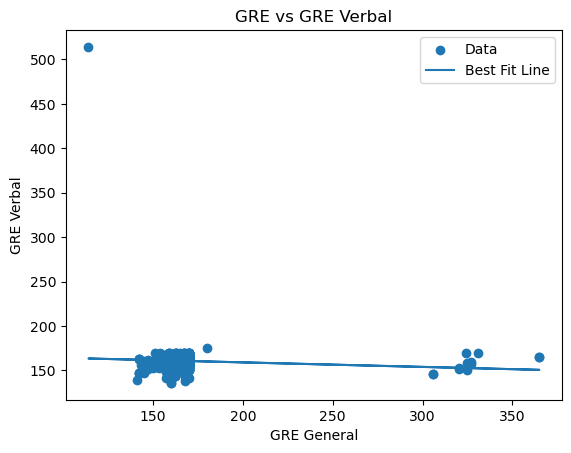

In [30]:
import matplotlib.pyplot as plt

# Filter valid values
plot_df = df[(df["gre_general"] > 0) & (df["gre_verbal"] > 0)]

x = plot_df["gre_general"]
y = plot_df["gre_verbal"]

# Best-fit line
m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x, m*x + b, label="Best Fit Line")

plt.title("GRE vs GRE Verbal")
plt.xlabel("GRE General")
plt.ylabel("GRE Verbal")
plt.legend()

plt.savefig("GRE-vs-GRE-V.png")
plt.show()

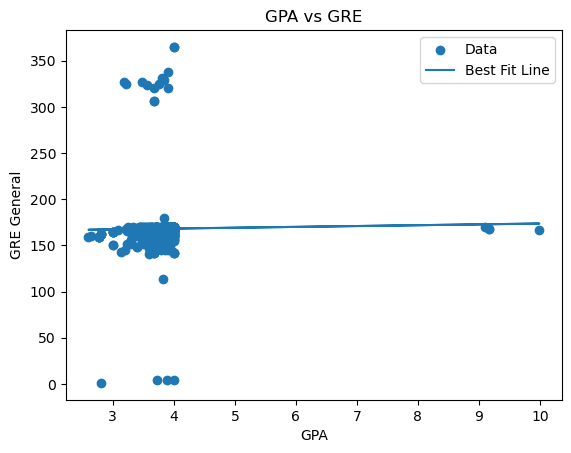

In [31]:
plot_df = df[(df["undergrad_gpa"] > 0) & (df["gre_general"] > 0)]

x = plot_df["undergrad_gpa"]
y = plot_df["gre_general"]

m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x, m*x + b, label="Best Fit Line")

plt.title("GPA vs GRE")
plt.xlabel("GPA")
plt.ylabel("GRE General")
plt.legend()

plt.savefig("GPA-vs-GRE.png")
plt.show()

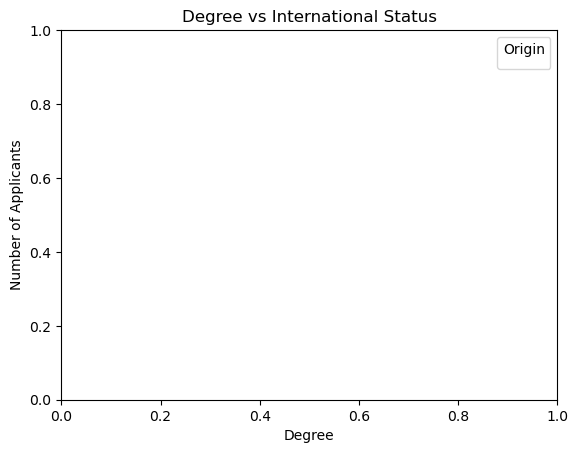

In [32]:
degree_counts = pd.crosstab(df["degree"], df["country_of_origin"])

degree_counts.plot(kind="bar")

plt.title("Degree vs International Status")
plt.xlabel("Degree")
plt.ylabel("Number of Applicants")
plt.legend(title="Origin")

plt.savefig("Degree-vs-International.png")
plt.show()

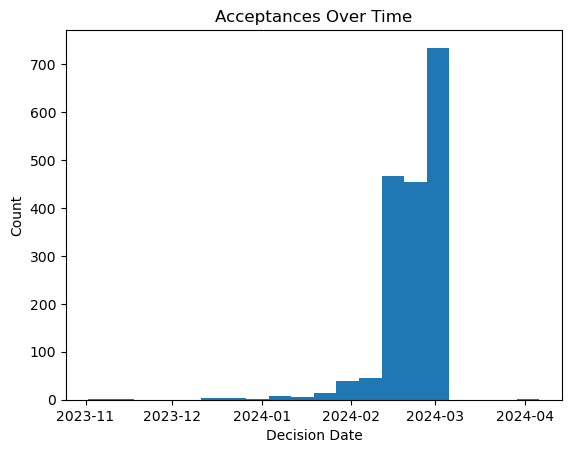

In [33]:
accepted_df = df[df["outcome"] == "Accepted"]

plt.figure()
plt.hist(accepted_df["decision_date"].dropna(), bins=20)

plt.title("Acceptances Over Time")
plt.xlabel("Decision Date")
plt.ylabel("Count")

plt.savefig("Acceptances-over-Time.png")
plt.show()

In [34]:
plt.figure()
df.boxplot(column="undergrad_gpa", by="outcome")

plt.title("GPA by Outcome")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("GPA")

plt.savefig("GPA-by-Outcome.png")
plt.show()

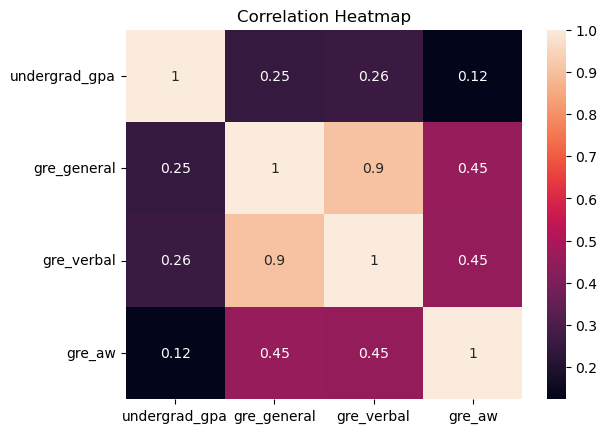

In [35]:
import seaborn as sns

corr = df[["undergrad_gpa", "gre_general", "gre_verbal", "gre_aw"]].corr()

plt.figure()
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.savefig("Numeric-Correlation-Heatmap.png")
plt.show()

In [36]:
df.to_json("cleaned_gradcafe.json", orient="records")
print("Saved cleaned dataset locally.")

Saved cleaned dataset locally.


In [37]:
import boto3

s3 = boto3.client("s3")

bucket_name = "amazon-sagemaker-313730224547-us-east-1-5epobvmonaep0n"
file_name = "cleaned_gradcafe.json"

s3.upload_file(file_name, bucket_name, file_name)

print("Upload successful!")

Upload successful!
